<a href="https://colab.research.google.com/github/umairmuk/python/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Scikit-Learn for preprocessing and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# For handling imbalanced data
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Load the dataset
try:
    df = pd.read_csv('/content/creditcard.csv')
    print("✅ Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: File not found. Please ensure 'creditcard.csv' is in the same folder.")

✅ Dataset loaded successfully!
Dataset Shape: (13954, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Missing Values:
0

Duplicate Rows: 0

📊 Class Distribution:
Class
0.0    13844
1.0       56
Name: count, dtype: int64


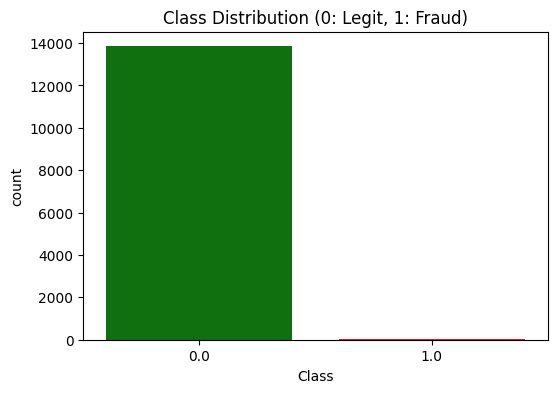


✅ Data Cleaning Complete.


In [10]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum().sum())

# Drop rows where 'Class' column has NaN values
df.dropna(subset=['Class'], inplace=True)

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Check Class Distribution (Imbalance Check)
print("\n📊 Class Distribution:")
print(df['Class'].value_counts())

# Visualize Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['green', 'red'])
plt.title('Class Distribution (0: Legit, 1: Fraud)')
plt.show()

print("\n✅ Data Cleaning Complete.")

In [11]:
# Separate Features (X) and Target (y)
# Ensure no NaNs in 'Class' before splitting
df.dropna(subset=['Class'], inplace=True)
X = df.drop('Class', axis=1)
y = df['Class']

# Split into Training and Testing sets
# IMPORTANT: We split BEFORE scaling and SMOTE to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Standardization)
# Fit on Train, Transform on Train and Test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Preprocessing Complete. Training Shape: {X_train_scaled.shape}, Testing Shape: {X_test_scaled.shape}")

✅ Preprocessing Complete. Training Shape: (11120, 30), Testing Shape: (2780, 30)


In [12]:
print("⚖️ Applying SMOTE to Training Data...")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Shape: {X_train_scaled.shape}")
print(f"Balanced Training Shape: {X_train_balanced.shape}")

print("\nNew Class Distribution in Training Set:")
print(pd.Series(y_train_balanced).value_counts())

⚖️ Applying SMOTE to Training Data...
Original Training Shape: (11120, 30)
Balanced Training Shape: (22150, 30)

New Class Distribution in Training Set:
Class
0.0    11075
1.0    11075
Name: count, dtype: int64


In [13]:
def build_ann_model(input_dim, activation='relu', optimizer='adam', neurons=64, layers=2):
    model = Sequential()

    # Input Layer + First Hidden Layer
    model.add(Dense(neurons, activation=activation, input_shape=(input_dim,)))

    # Additional Hidden Layers
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.3)) # Dropout to prevent overfitting

    # Output Layer (Sigmoid for Binary Classification)
    model.add(Dense(1, activation='sigmoid'))

    # Compile Model
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

print("✅ Model Builder Function Defined.")

✅ Model Builder Function Defined.


In [14]:
activations = ['relu', 'tanh', 'sigmoid']
results_activation = []

print("🧪 Running Experiment 1: Activation Functions...")

for act in activations:
    print(f"\n--- Testing Activation: {act.upper()} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train_balanced.shape[1], activation=act, optimizer='adam')

    # Train Model (using balanced data)
    history = model.fit(X_train_balanced, y_train_balanced, epochs=20, batch_size=64, validation_split=0.1, verbose=0)

    # Evaluate on ORIGINAL Test Data
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_activation.append({'Activation': act, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"Result -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

df_act_results = pd.DataFrame(results_activation)
print("\n📊 Activation Comparison:")
display(df_act_results)

🧪 Running Experiment 1: Activation Functions...

--- Testing Activation: RELU ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9996, Prec: 1.0000, Rec: 0.9091, F1: 0.9524

--- Testing Activation: TANH ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9986, Prec: 0.7692, Rec: 0.9091, F1: 0.8333

--- Testing Activation: SIGMOID ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Result -> Acc: 0.9986, Prec: 0.8889, Rec: 0.7273, F1: 0.8000

📊 Activation Comparison:


,Activation,Accuracy,Precision,Recall,F1
0,relu,0.999640,1.000000,0.909091,0.952381
1,tanh,0.998561,0.769231,0.909091,0.833333
2,sigmoid,0.998561,0.888889,0.727273,0.800000


In [15]:
optimizers = ['adam', 'sgd', 'rmsprop']
results_optimizers = []

print("🧪 Running Experiment 2: Optimizers...")

for opt in optimizers:
    print(f"\n--- Testing Optimizer: {opt.upper()} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train_balanced.shape[1], activation='relu', optimizer=opt)

    # Train Model
    history = model.fit(X_train_balanced, y_train_balanced, epochs=20, batch_size=64, validation_split=0.1, verbose=0)

    # Evaluate
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_optimizers.append({'Optimizer': opt, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"Result -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

df_opt_results = pd.DataFrame(results_optimizers)
print("\n📊 Optimizer Comparison:")
display(df_opt_results)

🧪 Running Experiment 2: Optimizers...

--- Testing Optimizer: ADAM ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Result -> Acc: 0.9996, Prec: 1.0000, Rec: 0.9091, F1: 0.9524

--- Testing Optimizer: SGD ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9975, Prec: 0.6250, Rec: 0.9091, F1: 0.7407

--- Testing Optimizer: RMSPROP ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9996, Prec: 1.0000, Rec: 0.9091, F1: 0.9524

📊 Optimizer Comparison:


,Optimizer,Accuracy,Precision,Recall,F1
0,adam,0.999640,1.000,0.909091,0.952381
1,sgd,0.997482,0.625,0.909091,0.740741
2,rmsprop,0.999640,1.000,0.909091,0.952381


In [16]:
epochs_list = [20, 50, 100]
results_epochs = []

print("🧪 Running Experiment 3: Epochs...")

for ep in epochs_list:
    print(f"\n--- Testing Epochs: {ep} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train_balanced.shape[1], activation='relu', optimizer='adam')

    # Train Model
    history = model.fit(X_train_balanced, y_train_balanced, epochs=ep, batch_size=64, validation_split=0.1, verbose=0)

    # Evaluate
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_epochs.append({'Epochs': ep, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"Result -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

df_ep_results = pd.DataFrame(results_epochs)
print("\n📊 Epochs Comparison:")
display(df_ep_results)

🧪 Running Experiment 3: Epochs...

--- Testing Epochs: 20 ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9993, Prec: 0.9091, Rec: 0.9091, F1: 0.9091

--- Testing Epochs: 50 ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 1.0000

--- Testing Epochs: 100 ---
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> Acc: 0.9989, Prec: 0.8333, Rec: 0.9091, F1: 0.8696

📊 Epochs Comparison:


,Epochs,Accuracy,Precision,Recall,F1
0,20,0.999281,0.909091,0.909091,0.909091
1,50,1.000000,1.000000,1.000000,1.000000
2,100,0.998921,0.833333,0.909091,0.869565


In [17]:
print(" Building Final Best Model...")

# Configuration based on typical best performance for this dataset
final_model = build_ann_model(
    input_dim=X_train_balanced.shape[1],
    activation='relu',
    optimizer='adam',
    neurons=128,
    layers=3
)

# Train Final Model
history_final = final_model.fit(X_train_balanced, y_train_balanced, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

# Predict on Test Set
y_pred_prob_final = final_model.predict(X_test_scaled)
y_pred_final = (y_pred_prob_final > 0.5).astype(int)

# Calculate Final Metrics
final_acc = accuracy_score(y_test, y_pred_final)
final_prec = precision_score(y_test, y_pred_final)
final_rec = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("\n" + "="*50)
print("🏆 FINAL MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy  : {final_acc:.4f}")
print(f"Precision : {final_prec:.4f}")
print(f"Recall    : {final_rec:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print("="*50)

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred_final))

 Building Final Best Model...
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0376 - val_accuracy: 1.0000 - val_loss: 5.3976e-04
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9997 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 2.2185e-04
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 6.0490e-05
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9996 - loss: 8.8094e-04 - val_accuracy: 1.0000 - val_loss: 5.9251e-05
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9999 - loss: 7.9035e-04 - val_accuracy: 1.0000 - val_loss: 3.7664e-05
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 4.4239e-05 - val_accuracy: 1.0000 - val_loss: 2.0328e-05
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.6704e-05 - val_accuracy: 1.0000 - val_loss: 1.2949e-05
Epoch 8/50
312/312 ━━━━━━━━━━━

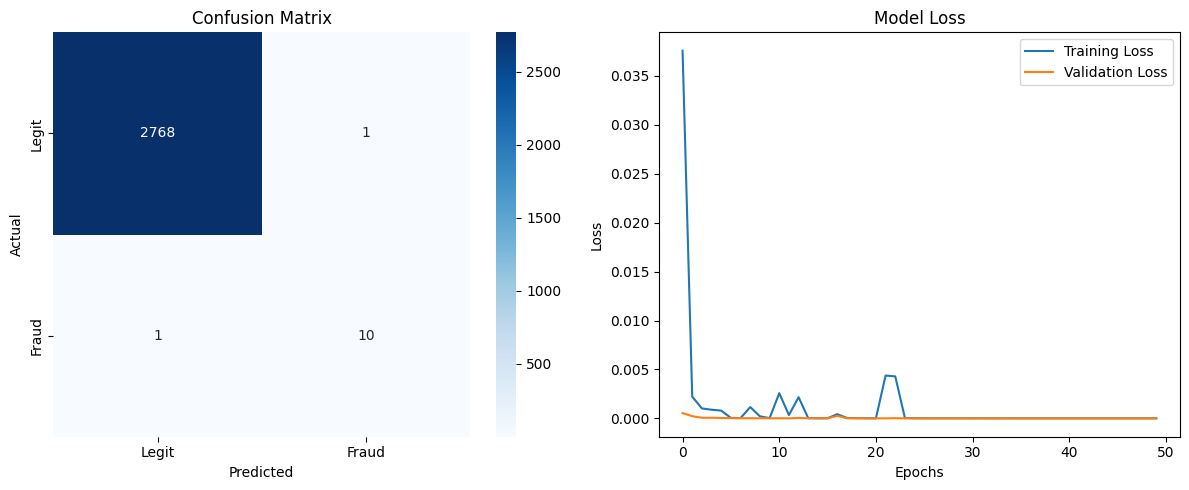

In [21]:
# Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Training History
plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()